In [1]:
import sys
sys.path.insert(0, './src/python')
#os.system("pip install global-land-mask")
sys.path.insert(0, '/home/581/da1339/.local/lib/python3.9/site-packages')
import os
import re
import fnmatch
import glob
import afim
import pygmt
import importlib
import xesmf              as xe
import numpy              as np
import pandas             as pd
import xarray             as xr
import cosima_cookbook    as cc
import matplotlib.pyplot  as plt
import cartopy.crs        as ccrs
import cmocean            as cm
import cartopy.feature    as cft
import matplotlib.path    as mpath
import metpy.calc         as mpc
from datetime             import datetime, timedelta
from dask.distributed     import Client
from matplotlib.animation import FuncAnimation
from matplotlib           import animation
from IPython.display      import HTML, display
from celluloid            import Camera
from osgeo                import gdal
from dask.diagnostics     import ProgressBar
from global_land_mask     import globe
%matplotlib inline

In [2]:
cice_prep = afim.cice_prep(os.path.join(os.path.expanduser('~'), 'src','python', 'afim_on_gadi.json'))

In [40]:
di  = 14
hpd = 24
ti0 = (di-1)*hpd
tiN = di*hpd
t0 = '2005-01-01'
tN = '2005-01-02'
nj0 = 0
njN = 1000
ERA5 = xr.open_dataset('/scratch/jk72/da1339/model_input/ERA5/monthly/ERA5_hourly_forcing_0p25_2005_01.nc',chunks={'time':'1'})
JRA55 = xr.open_dataset('/scratch/jk72/da1339/cice-dirs/input/AFIM/forcing/0p25/JRA55/8XDAILY/JRA55_03hr_forcing_tx1_2005.nc',chunks={'time':'1'})
#t2m_e = ERA5.airtmp.sel(time=slice(t0,tN)).mean(dim='time')
#t2m_e.plot(figsize=(15,12))
#t2m_j = JRA55.airtmp.sel(time=slice(t0,tN)).mean(dim='time')
#t2m_j.plot(figsize=(15,12))
#t2m_diff = t2m_e - t2m_j
#t2m_diff.plot(figsize=(15,12))
#ATM.airtmp.isel(time=slice(ti0,tiN)).mean(dim='time').isel(nj=slice(0,1000)).plot(figsize=(20,10))
#ATM.dlwsfc.isel(time=slice(ti0,tiN)).mean(dim='time').isel(nj=slice(0,1000)).plot(figsize=(20,10))
#ATM.glbrad.isel(time=slice(ti0,tiN)).mean(dim='time').isel(nj=slice(0,1000)).plot(figsize=(20,10))
#ATM.spchmd.isel(time=slice(ti0,tiN)).mean(dim='time').isel(nj=slice(0,1000)).plot(figsize=(20,10))
#ATM.ttlpcp.isel(time=slice(ti0,tiN)).mean(dim='time').isel(nj=slice(0,1000)).plot(figsize=(20,10))
#ATM.wndewd.isel(time=slice(ti0,tiN)).mean(dim='time').isel(nj=slice(0,1000)).plot(figsize=(20,10))
#ATM.wndnwd.isel(time=slice(ti0,tiN)).mean(dim='time').isel(nj=slice(0,1000)).plot(figsize=(20,10))

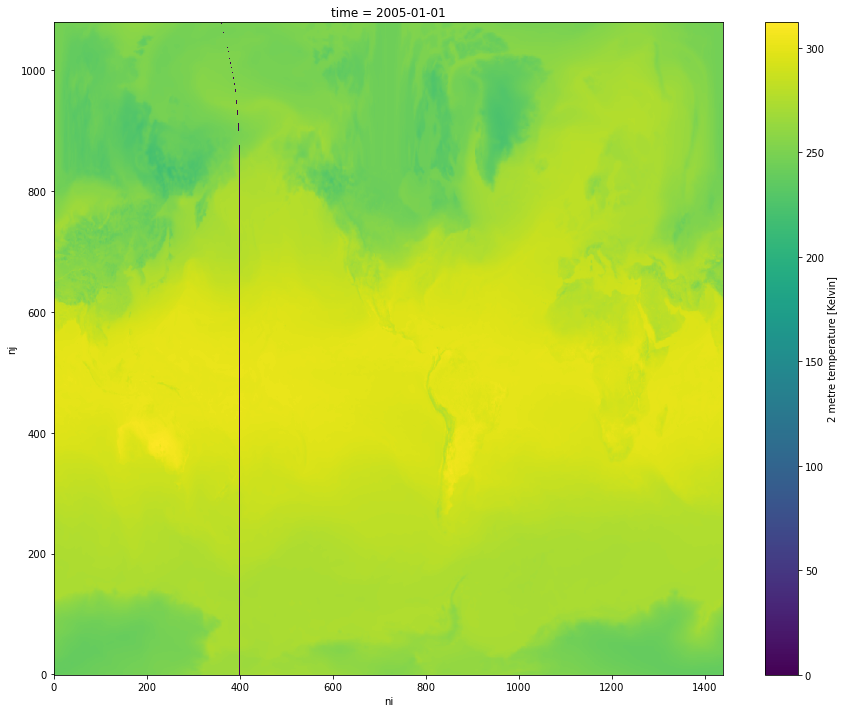

In [41]:
#ERA5['airtmp'] = ERA5.airtmp.where(ERA5.airtmp>150)
ERA5.airtmp.isel(time=0).plot(figsize=(15,12))

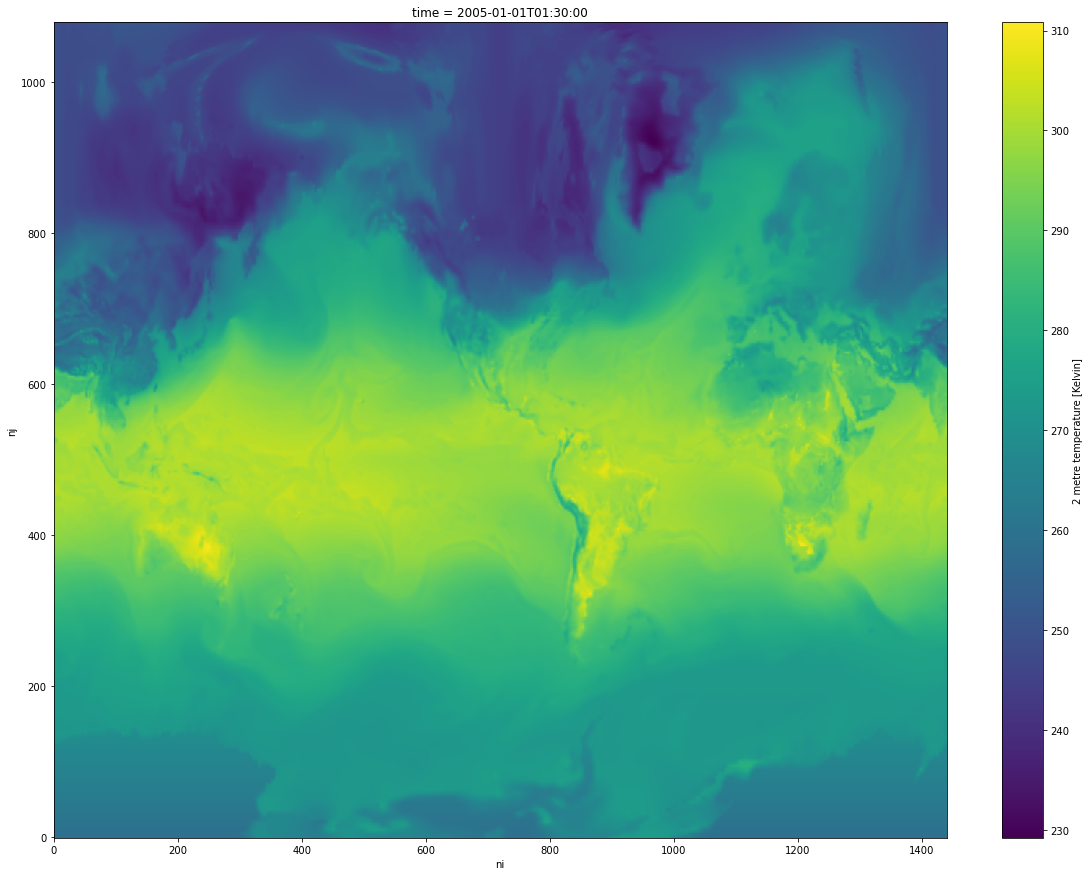

In [42]:
JRA55.airtmp.isel(time=0).plot(figsize=(20,15))

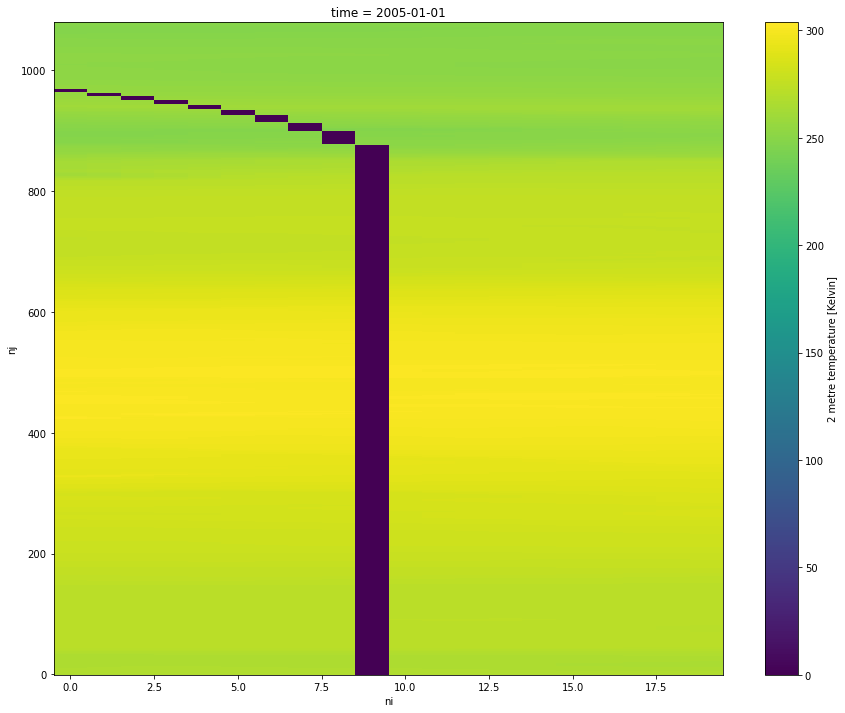

In [43]:
ERA5.airtmp.isel(time=0,ni=slice(390,410)).plot(figsize=(15,12))

In [65]:
yr_str        = '2005'
G_origin      = 'aom2'
G_res         = '0p25'
regrid_method = 'nearest_s2d'
regrid_prdcty = False
F_weights     = "/g/data/jk72/da1339/grids/weights/map_ERA5_{origin:s}_{res:s}_{method:s}.nc".format(origin=G_origin,res=G_res,method=regrid_method)
reuse_weights = False
G_CICE        = xr.open_dataset('/g/data/ik11/inputs/access-om2/input_20200530/cice_025deg/grid.nc')
G_CICE['lat'] = (['ny','nx'],G_CICE.tlat.values*(180/np.pi),{'units':'degrees_north'})
G_CICE['lon'] = (['ny','nx'],G_CICE.tlon.values*(180/np.pi),{'units':'degrees_east'})
print('Loading and regridding 2t')
ERA5_oG       = xr.open_mfdataset( os.path.join('/g/data/rt52/era5/single-levels/reanalysis','2t',yr_str,'*.nc') , chunks={"time":1} )
LON,LAT       = np.meshgrid(ERA5_oG.longitude.values,ERA5_oG.latitude.values)
G_ERA5        = xr.Dataset(data_vars={'lon':(('ny','nx'),LON),'lat':(('ny','nx'),LAT)})
rg            = xe.Regridder(G_ERA5, G_CICE, method=regrid_method,  periodic=regrid_prdcty, filename=F_weights, reuse_weights=reuse_weights)
t2m           = rg(ERA5_oG)
print('Loading and regridding msdwlwrf')
ERA5_oG       = xr.open_mfdataset( os.path.join('/g/data/rt52/era5/single-levels/reanalysis','msdwlwrf',yr_str,'*.nc') , chunks={"time":1} )
lw            = rg(ERA5_oG)
print('Loading and regridding msdwswrf')
ERA5_oG       = xr.open_mfdataset( os.path.join('/g/data/rt52/era5/single-levels/reanalysis','msdwswrf',yr_str,'*.nc') , chunks={"time":1} )
sw            = rg(ERA5_oG)
print('Loading and regridding mtpr')
ERA5_oG       = xr.open_mfdataset( os.path.join('/g/data/rt52/era5/single-levels/reanalysis','mtpr'    ,yr_str,'*.nc') , chunks={"time":1} )
mtpr          = rg(ERA5_oG)
print('Loading and regridding 10u')
ERA5_oG       = xr.open_mfdataset( os.path.join('/g/data/rt52/era5/single-levels/reanalysis','10u'     ,yr_str,'*.nc') , chunks={"time":1} )
u10           = rg(ERA5_oG)
print('Loading and regridding 10v')
ERA5_oG       = xr.open_mfdataset( os.path.join('/g/data/rt52/era5/single-levels/reanalysis','10v'     ,yr_str,'*.nc') , chunks={"time":1} )
v10           = rg(ERA5_oG)
print('Loading and regridding 2d')
ERA5_oG       = xr.open_mfdataset( os.path.join('/g/data/rt52/era5/single-levels/reanalysis','2d'      ,yr_str,'*.nc') , chunks={"time":1} )
d2m           = rg(ERA5_oG)
print('Loading and regridding sp')
ERA5_oG       = xr.open_mfdataset( os.path.join('/g/data/rt52/era5/single-levels/reanalysis','sp'      ,yr_str,'*.nc') , chunks={"time":1} )
sp            = rg(ERA5_oG)
print('Computing qsat')
qsat          = afim.compute_sfc_qsat(d2m.d2m,sp.sp)
print("Data array sizes (GB):")
print("\t airtmp: ", t2m.t2m.astype(np.single).nbytes / (1024**3))
print("\t dlwsfc: ", lw.msdwlwrf.astype(np.single).nbytes / (1024**3))
print("\t glbrad: ", sw.msdwswrf.astype(np.single).nbytes / (1024**3))
print("\t spchmd: ", qsat.astype(np.single).nbytes / (1024**3))
print("\t ttlpcp: ", mtpr.mtpr.astype(np.single).nbytes / (1024**3))
print("\t wndewd: ", u10.u10.astype(np.single).nbytes / (1024**3))
print("\t wndnwd: ", v10.v10.astype(np.single).nbytes / (1024**3))
d_vars = {"airtmp" : (['time','ny','nx'],t2m.t2m.astype(np.single).data,
                      {'long_name' :"2 metre temperature",
                       'units'     :"Kelvin"}),
          "dlwsfc" : (['time','ny','nx'],lw.msdwlwrf.astype(np.single).data,
                      {'long_name':"Mean surface downward long-wave radiation flux",
                       'units'    :"W m**-2"}),
          "glbrad" : (['time','ny','nx'],sw.msdwswrf.astype(np.single).data,
                      {'long_name':"Mean surface downward short-wave radiation flux",
                       'units'    :"W m**-2"}),
          "spchmd" : (['time','ny','nx'],qsat.astype(np.single).data,
                      {'long_name':"specific humidity",
                       'units'    :"kg/kg"}),
          "ttlpcp" : (['time','ny','nx'],mtpr.mtpr.astype(np.single).data,
                      {'long_name':"Mean total precipitation rate",
                       'units'    :"kg m**-2 s**-1"}),
          "wndewd" : (['time','ny','nx'],u10.u10.astype(np.single).data,
                      {'long_name':"10 metre meridional wind component",
                       'units'    :"m s**-1"}),
          "wndnwd" : (['time','ny','nx'],v10.v10.astype(np.single).data,
                      {'long_name':"10 metre zonal wind component",
                       'units'    :"m s**-1"}) }
coords = {"LON"  : (["ny","nx"],G_CICE.lon.data,{'units':'degrees_east'}),
          "LAT"  : (["ny","nx"],G_CICE.lat.data,{'units':'degrees_north'}),
          "time" : (["time"],t2m.time.data)}
attrs = {'creation_date': datetime.now().strftime('%Y-%m-%d %H'),
         'conventions'  : "CCSM data model domain description -- for CICE6 standalone 'JRA55' atmosphere option",
         'title'        : "re-gridded ERA5 for CICE6 standalone atmosphere forcing",
         'source'       : "ERA5, https://doi.org/10.1002/qj.3803, ",
         'comment'      : "source files found on gadi, /g/data/rt52/era5/single-levels/reanalysis",
         'note1'        : "ERA5 documentation, https://confluence.ecmwf.int/display/CKB/ERA5%3A+data+documentation",
         'note2'        : "regridding weight file, {:s}".format(F_weights),
         'note3'        : "re-gridded using ESMF_RegridGenWeights",
         'author'       : 'Daniel P Atwater',
         'email'        : 'daniel.atwater@utas.edu.au'}
ATM   = xr.Dataset(data_vars=d_vars,coords=coords,attrs=attrs)

Loading and regridding 2t
Loading and regridding msdwlwrf
Loading and regridding msdwswrf
Loading and regridding mtpr
Loading and regridding 10u
Loading and regridding 10v
Loading and regridding 2d
Loading and regridding sp
Computing qsat
Data array sizes (GB):
	 airtmp:  50.751686096191406
	 dlwsfc:  50.751686096191406
	 glbrad:  50.751686096191406
	 spchmd:  50.751686096191406
	 ttlpcp:  50.751686096191406
	 wndewd:  50.751686096191406
	 wndnwd:  50.751686096191406


In [78]:
import nctoolkit as nc
nc.options(parallel = True)
print('Writing out netcdf file ... which can take a very long time')
D_out = '/scratch/jk72/da1339/cice-dirs/input/AFIM/forcing/0p25/ERA5/8XDAILY'
F_out = "ERA5_{yr:s}_with_jra55do_var_names_reG_{meth:s}_{res:s}_{org:s}.nc".format(yr=yr_str,meth=regrid_method,res=G_res,org=G_origin)
P_out = os.path.join(D_out,F_out)
ATM2  = nc.from_xarray(ATM)
ATM2.to_nc(P_out,overwrite = True)#unlimited_dims=['time'],compute=False)
#print(f"Writing to {P_out}")
#Thread(target=write).start()
#with ProgressBar(): write.compute()

Writing out netcdf file ... which can take a very long time


KeyboardInterrupt: 

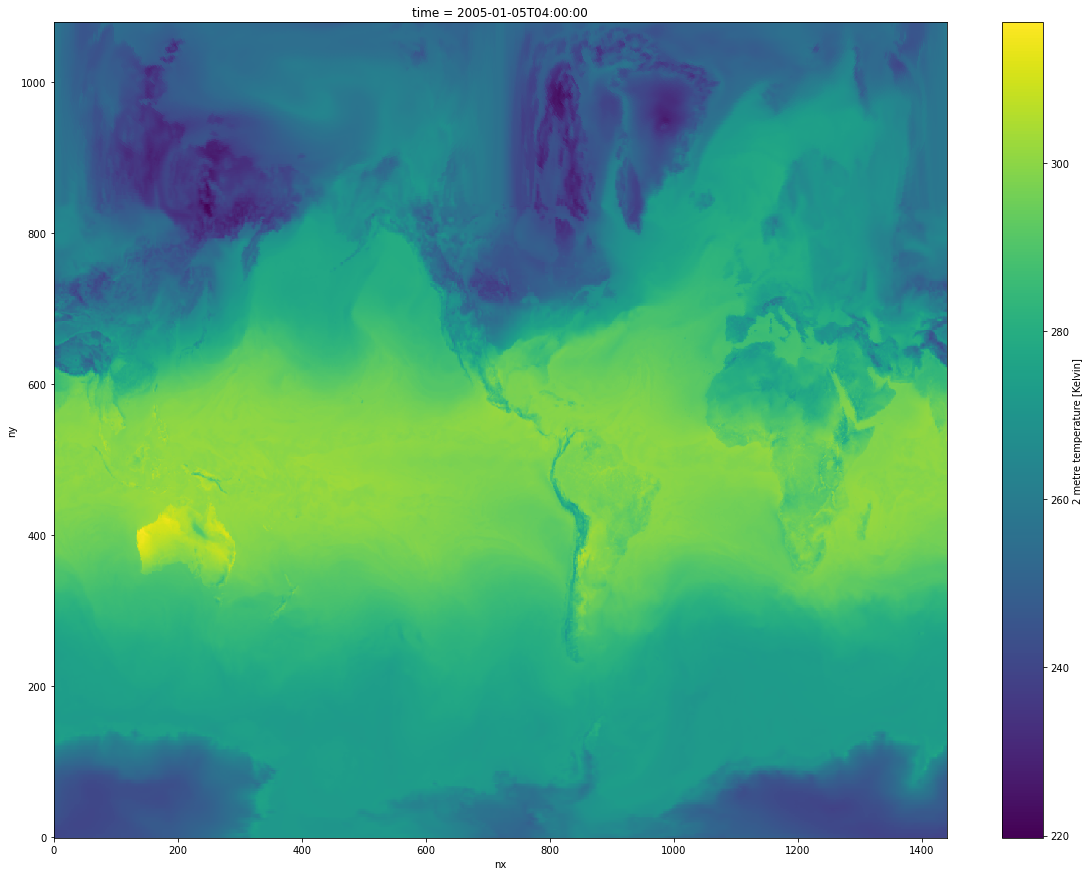

In [66]:
ATM.airtmp.isel(time=100).plot(figsize=(20,15))

In [4]:
ulon025         = np.linspace(-180.25, 180.25, num=360*4)
ulat025         = np.linspace(-89.75, 89.75, num=180*4)
uGln025,uGlt025 = np.meshgrid(ulon025,ulat025)
tlon025         = np.linspace(-180, 180, num=360*4)
tlat025         = np.linspace(-90, 90, num=180*4)
tGln025,tGlt025 = np.meshgrid(tlon025,tlat025)
tlon_diff       = np.diff(tGln025,prepend=tlon025[0])
tlat_diff       = np.diff(tGlt025,prepend=tlat025[0])
ulon_diff       = np.diff(uGln025,prepend=ulon025[0])
ulat_diff       = np.diff(uGlt025,prepend=ulat025[0])
tangle          = np.arctan2(tlat_diff, tlon_diff)
uangle          = np.arctan2(ulat_diff, ulon_diff)
tlon_diff_rad   = np.radians(tlon_diff)
tlat_diff_rad   = np.radians(tlat_diff)
ulon_diff_rad   = np.radians(ulon_diff)
ulat_diff_rad   = np.radians(ulat_diff)
earth_radius_m  = 6_371_000
earth_radius_cm = earth_radius_m * 100 #in cm
tcell_width_lon = earth_radius_cm * np.cos(np.radians(tGlt025)) * tlon_diff_rad# * 100
tcell_width_lat = earth_radius_cm * tlat_diff_rad# * 100
tcell_area      = (earth_radius_m ** 2) * np.abs(tlat_diff_rad * tlon_diff_rad * np.cos(tlat_diff_rad))
ucell_area      = (earth_radius_m ** 2) * np.abs(ulat_diff_rad * ulon_diff_rad * np.cos(ulat_diff_rad))
G025            = xr.Dataset(data_vars = {"tlon"   : (['ny','nx'],tGln025.astype(np.single),
                                           {'long_name' : "longitude",
                                            'units'     : "degrees east"}),
                               "tlat"   : (['ny','nx'],tGlt025.astype(np.single),
                                           {'long_name' : "latitude",
                                            'units'     : "degrees north"}),
                               "ulon"   : (['ny','nx'],uGln025.astype(np.single),
                                           {'long_name' : "longitude",
                                            'units'     : "degrees east"}),
                               "ulat"   : (['ny','nx'],uGlt025.astype(np.single),
                                           {'long_name' : "latitude",
                                            'units'     : "degrees north"}),
                               "hte"    : (['ny','nx'],tcell_width_lon.astype(np.single),
                                           {'long_name' : "width of T cells on east side",
                                            'units'     : "cm"}),
                               "htn"    : (['ny','nx'],tcell_width_lat.astype(np.single),
                                           {'long_name' : "width of T cells on north side",
                                            'units'     : "cm"}),
                               "angle"  : (['ny','nx'],uangle.astype(np.single),
                                           {'long_name' : "rotation angle of U cells",
                                            'units'     : "radians"}),
                               "angleT" : (['ny','nx'],tangle.astype(np.single),
                                           {'long_name' : "rotation angle of T cells",
                                            'units'     : "radians"}),
                               "tarea"  : (['ny','nx'],tcell_area.astype(np.single),
                                           {'long_name' : "area T cells",
                                            'units'     : "m**2"}),
                               "uarea"  : (['ny','nx'],ucell_area.astype(np.single),
                                           {'long_name' : "area U cells",
                                            'units'     : "m**2"}),
                              })
#G025.to_netcdf('/scratch/jk72/da1339/cice-dirs/input/AFIM/grid/0p25/grid_rectilinear.nc')

<xarray.Dataset>
Dimensions:  (ny: 720, nx: 1440)
Dimensions without coordinates: ny, nx
Data variables:
    tlon     (ny, nx) float32 -180.0 -179.7 -179.5 -179.2 ... 179.5 179.7 180.0
    tlat     (ny, nx) float32 -90.0 -90.0 -90.0 -90.0 ... 90.0 90.0 90.0 90.0
    ulon     (ny, nx) float32 -180.2 -180.0 -179.7 -179.5 ... 179.7 180.0 180.2
    ulat     (ny, nx) float32 -89.75 -89.75 -89.75 -89.75 ... 89.75 89.75 89.75
    hte      (ny, nx) float32 0.0 1.703e-10 1.703e-10 ... 1.703e-10 1.703e-10
    htn      (ny, nx) float32 0.0 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
    angle    (ny, nx) float32 0.0 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
    angleT   (ny, nx) float32 0.0 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
    tarea    (ny, nx) float32 0.0 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
    uarea    (ny, nx) float32 0.0 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0

In [36]:
from scipy.interpolate import tripolar

# Define the grid parameters
num_lon = 180
num_lat = 90

# Generate the latitude and longitude coordinates
lon = np.linspace(0, 360, num_lon)
lat = np.linspace(-90, 90, num_lat)

# Create the tripolar grid
grid = tripolar.TripolarGrid(lon, lat)

# Get the grid coordinates
grid_lon, grid_lat = grid.get_grid()

# Plot the grid
plt.scatter(grid_lon, grid_lat, s=1)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Tripolar Grid')
plt.show()

ImportError: cannot import name 'tripolar' from 'scipy.interpolate' (/g/data/hh5/public/apps/miniconda3/envs/analysis3-22.07/lib/python3.9/site-packages/scipy/interpolate/__init__.py)

In [5]:
kmt025 = globe.is_ocean(tGlt025,tGln025)
KMT025 = xr.Dataset(data_vars = {"kmt" : (['ny','nx'],np.where(kmt025,1,0).astype(np.int),
                                          {'standard_name' : "ocean fraction at T-cell centers",
                                           'units'         : "none"})})
#KMT025.to_netcdf('/scratch/jk72/da1339/cice-dirs/input/AFIM/grid/0p25/kmt_rectilinear.nc')

<xarray.Dataset>
Dimensions:  (ny: 720, nx: 1440)
Dimensions without coordinates: ny, nx
Data variables:
    kmt      (ny, nx) int64 0 0 0 0 0 0 0 0 0 0 0 0 ... 1 1 1 1 1 1 1 1 1 1 1 1

In [41]:
yr_str = '2005'
G_ERA5 = cice_prep.era5_grid_prep()
G025['lon'] = G025.tlon
G025['lat'] = G025.tlat
rg     = xe.Regridder(G_ERA5, G025, method='nearest_s2d',  periodic='false', filename='/g/data/jk72/da1339/grids/weights/map_ERA5_rectilinear_cice_0p25_nearest.nc', reuse_weights=False)
tmp    = cice_prep.era5_load(era5_var='2t',yr_str=yr_str)
t2m    = rg(tmp)
#t2m    = cice_prep.era5_load(era5_var = '2t'      , yr_str = yr_str)
tmp    = cice_prep.era5_load(era5_var = 'msdwlwrf', yr_str = yr_str)
lw     = rg(tmp)
tmp    = cice_prep.era5_load(era5_var = 'msdwswrf', yr_str = yr_str)
sw     = rg(tmp)
tmp    = cice_prep.era5_load(era5_var = 'mtpr'    , yr_str = yr_str)
mtpr   = rg(tmp)
tmp    = cice_prep.era5_load(era5_var = '10u'     , yr_str = yr_str)
u10    = rg(tmp)
tmp    = cice_prep.era5_load(era5_var = '10v'     , yr_str = yr_str)
v10    = rg(tmp)
tmp    = cice_prep.era5_load(era5_var = '2d'      , yr_str = yr_str)
d2m    = rg(tmp)
tmp    = cice_prep.era5_load(era5_var = 'sp'      , yr_str = yr_str)
sp     = rg(tmp)
qsat   = afim.compute_sfc_qsat(d2m.d2m, sp.sp)
print(t2m)
print("Data array sizes (GB):")
print("\t airtmp: ", t2m.t2m.nbytes / (1024**3))
print("\t dlwsfc: ", lw.msdwlwrf.nbytes / (1024**3))
print("\t glbrad: ", sw.msdwswrf.nbytes / (1024**3))
print("\t spchmd: ", qsat.nbytes / (1024**3))
print("\t ttlpcp: ", mtpr.mtpr.nbytes / (1024**3))
print("\t wndewd: ", u10.u10.nbytes / (1024**3))
print("\t wndnwd: ", v10.v10.nbytes / (1024**3))
print("Data array sizes (GB):")
print("\t airtmp: ", t2m.t2m.astype(np.single).nbytes / (1024**3))
print("\t dlwsfc: ", lw.msdwlwrf.astype(np.single).nbytes / (1024**3))
print("\t glbrad: ", sw.msdwswrf.astype(np.single).nbytes / (1024**3))
print("\t spchmd: ", qsat.astype(np.single).nbytes / (1024**3))
print("\t ttlpcp: ", mtpr.mtpr.astype(np.single).nbytes / (1024**3))
print("\t wndewd: ", u10.u10.astype(np.single).nbytes / (1024**3))
print("\t wndnwd: ", v10.v10.astype(np.single).nbytes / (1024**3))
d_vars = {"airtmp" : (['time','ny','nx'],t2m.t2m.astype(np.single).data,
                      {'long_name' :"2 metre temperature",
                       'units'     :"Kelvin"}),
          "dlwsfc" : (['time','ny','nx'],lw.msdwlwrf.astype(np.single).data,
                      {'long_name':"Mean surface downward long-wave radiation flux",
                       'units'    :"W m**-2"}),
          "glbrad" : (['time','ny','nx'],sw.msdwswrf.astype(np.single).data,
                      {'long_name':"Mean surface downward short-wave radiation flux",
                       'units'    :"W m**-2"}),
          "spchmd" : (['time','ny','nx'],qsat.astype(np.single).data,
                      {'long_name':"specific humidity",
                       'units'    :"kg/kg"}),
          "ttlpcp" : (['time','ny','nx'],mtpr.mtpr.astype(np.single).data,
                      {'long_name':"Mean total precipitation rate",
                       'units'    :"kg m**-2 s**-1"}),
          "wndewd" : (['time','ny','nx'],u10.u10.astype(np.single).data,
                      {'long_name':"10 metre meridional wind component",
                       'units'    :"m s**-1"}),
          "wndnwd" : (['time','ny','nx'],v10.v10.astype(np.single).data,
                      {'long_name':"10 metre zonal wind component",
                       'units'    :"m s**-1"}) }
coords = {"LON"  : (["ny","nx"],G025.tlon.data,{'units':'degrees_east'}),
          "LAT"  : (["ny","nx"],G025.tlat.data,{'units':'degrees_north'}),
          "time" : (["time"],t2m.time.data)}
attrs = {'creation_date': datetime.now().strftime('%Y-%m-%d %H'),
         'conventions'  : "CCSM data model domain description -- for CICE6 standalone 'JRA55' atmosphere option",
         'title'        : "re-gridded ERA5 for CICE6 standalone ocean forcing",
         'source'       : "ERA5, https://doi.org/10.1002/qj.3803, ",
         'comment'      : "source files found on gadi, /g/data/rt52/era5/single-levels/reanalysis",
         'note1'        : "ERA5 documentation, https://confluence.ecmwf.int/display/CKB/ERA5%3A+data+documentation",
         'note2'        : "regridding weight file, /g/data/jk72/da1339/grids/weights/map_ERA5_access-om2_cice_0p1_bilinear.nc",
         'note3'        : "re-gridded using ESMF_RegridGenWeights",
         'author'       : 'Daniel P Atwater',
         'email'        : 'daniel.atwater@utas.edu.au'}
ATM = xr.Dataset(data_vars=d_vars,coords=coords,attrs=attrs)
ATM.to_netcdf('cice-dirs/input/AFIM/forcing/0p25/ERA5/8XDAILY/ERA5_2005_with_jra55do_var_names_for_cice6p4_regridded_from_rectilinear.nc')

In [34]:
yr_str       = '2005'
G_BRANt      = cice_prep.bran_grid_prep(grid_type='t')
G_BRANu      = cice_prep.bran_grid_prep(grid_type='u')
G025t['lon'] = G025.tlon
G025t['lat'] = G025.tlat
G025u['lon'] = G025.ulon
G025u['lat'] = G025.ulat
temp         = cice_prep.bran_load(bran_var='temp',yr_str=yr_str)
sst          = temp.isel(st_ocean=0).drop(['st_ocean','average_T1','average_T2','average_DT','Time_bounds','nv','st_edges_ocean'])
salt         = cice_prep.bran_load(bran_var='salt',yr_str=yr_str)
sss          = salt.isel(st_ocean=0).drop(['st_ocean','average_T1','average_T2','average_DT','Time_bounds','nv','st_edges_ocean'])
uocn         = cice_prep.bran_load(bran_var = 'u', yr_str = yr_str)
u            = uocn.isel(st_ocean=0).drop(['st_ocean','average_T1','average_T2','average_DT','Time_bounds','nv','st_edges_ocean'])
vocn         = cice_prep.bran_load(bran_var='v',yr_str=yr_str)
v            = vocn.isel(st_ocean=0).drop(['st_ocean','average_T1','average_T2','average_DT','Time_bounds','nv','st_edges_ocean'])
rgt          = xe.Regridder(G_BRANt, G025u, method='nearest_s2d', periodic='false',
                            filename='/g/data/jk72/da1339/grids/weights/map_BRAN_rectilinear_cice_0p25_nearest.nc', 
                            reuse_weights=False)
rgu          = xe.Regridder(G_BRANu, G025u, method='nearest_s2d',  periodic='false',
                            filename='/g/data/jk72/da1339/grids/weights/map_BRAN_rectilinear_cice_0p25_nearest.nc',
                            reuse_weights=False)
sst          = rgt(sst)
sss          = rgt(sss)
u            = rgu(u)
v            = rgu(v)

In [35]:
print("Data array sizes (GB):")
print("\t sst: ", sst.temp.nbytes / (1024**3))
print("\t sss: ", sss.salt.nbytes / (1024**3))
print("\t uon: ", u.u.nbytes / (1024**3))
print("\t von: ", v.v.nbytes / (1024**3))
print("Data array sizes (GB):")
print("\t sst: ", sst.temp.astype(np.single).nbytes / (1024**3))
print("\t sss: ", sss.salt.astype(np.single).nbytes / (1024**3))
print("\t uon: ", u.u.astype(np.single).nbytes / (1024**3))
print("\t von: ", v.v.astype(np.single).nbytes / (1024**3))
d_vars = {"sst" : (['time','ny','nx'],sst.temp.astype(np.single).data,
                      {'long_name' :"sea surface temperature",
                       'units'     :"C"}),
          "sss" : (['time','ny','nx'],sss.salt.astype(np.single).data,
                      {'long_name':"sea surface salinity",
                       'units'    :"psu"}),
          "u"   : (['time','ny','nx'],u.u.astype(np.single).data,
                      {'long_name':"meridional surface curent",
                       'units'    :"m/s"}),
          "v"   : (['time','ny','nx'],v.v.astype(np.single).data,
                      {'long_name':"zonal surface current",
                       'units'    :"m/s"})}
coords = {"tLON"  : (["ny","nx"],G025.tlon.data,{'units':'degrees_east'}),
          "tLAT"  : (["ny","nx"],G025.tlat.data,{'units':'degrees_north'}),
          "uLON"  : (["ny","nx"],G025.ulon.data,{'units':'degrees_east'}),
          "uLAT"  : (["ny","nx"],G025.ulat.data,{'units':'degrees_north'}),
          "time" : (["time"],sst.Time.data)}
attrs = {'creation_date': datetime.now().strftime('%Y-%m-%d %H'),
         'conventions'  : 'CCSM data model domain description -- for CICE6 standalone "DEFAULT" ocean option',
         'title'        : 'daily averaged ocean forcing from BRAN2020 output for CICE6 standalone ocean forcing',
         'source'       : 'BRAN2020',
         'comment'      : 'source files found on gadi, /g/data/gb6/BRAN/BRAN2020',
         'calendar'     : 'standard',
         'note1'        : 'grid is rectangular Arkawa B-grid',
         'author'       : 'Daniel P Atwater',
         'email'        : 'daniel.atwater@utas.edu.au'}
OCN = xr.Dataset(data_vars=d_vars,coords=coords,attrs=attrs)
OCN.to_netcdf('cice-dirs/input/AFIM/forcing/0p25/ocean/daily/BRAN_2005_var_names_for_cice6p4_DEFAULT_regrid_to_recti0p25_B-grid.nc')

Data array sizes (GB):
	 sst:  1.409769058227539
	 sss:  1.409769058227539
	 uon:  1.409769058227539
	 von:  1.409769058227539
Data array sizes (GB):
	 sst:  1.409769058227539
	 sss:  1.409769058227539
	 uon:  1.409769058227539
	 von:  1.409769058227539


In [ ]:
regridder = xe.Regridder(t2m.isel(time=0), ds_out, "nearest_s2d")
dr_out = regridder(t2m)

In [ ]:
t2m.t2m.isel(time=0).plot(figsize=(20,15))

In [ ]:
dr_out.t2m.isel(time=0).plot(figsize=(20,15))

In [ ]:
rg    = xe.Regridder(dr_out, G_CICE, method='patch',periodic=False)#,  periodic='false', filename='/g/data/jk72/da1339/grids/weights/map_ERA5_access-om2_cice_0p25_conservative.nc', reuse_weights=False)
ds_rg = rg(dr_out)
ds_rg.t2m.isel(time=0).plot(figsize=(20,15))

In [ ]:
dr_out

In [ ]:
ds_rg

In [ ]:
D_ATM     = os.path.join(cice_prep.D_modin,'ERA5')
D_ATM_tmp = os.path.join(D_ATM,'monthly')
cnt = 0
dt_obj = cice_prep.define_datetime_object(start_date='', year_offset=0)
mo0_dates = pd.date_range(start=dt_obj,freq='MS',periods=cice_prep.n_months)
moN_dates = pd.date_range(start=dt_obj,freq='M',periods=cice_prep.n_months)
enc_dict  = {'shuffle':True,'zlib':True,'complevel':5}
for j in mo0_dates:
    dt0_str   = j.strftime('%Y-%m-%d %H:%M')
    dtN_str   = moN_dates[cnt].strftime('%Y-%m-%d %H:%M')
    yrmo0_str = j.strftime('%Y_%m')
    P_ATM_tmp = os.path.join(D_ATM_tmp,cice_prep.F_ERA5_reG_form_tmp.format(res=cice_prep.G_res,dt_str=yrmo0_str))
    if not os.path.exists(P_ATM_tmp):
        ATM_tmp   = ATM.sel(time=slice(dt0_str,dtN_str))
        write_job = ATM_tmp.to_netcdf(P_ATM_tmp,unlimited_dims=['time'],compute=False)#,encoding={'airtmp':enc_dict,
                                                                                      #          'dlwsfc':enc_dict,
                                                                                      #          'glbrad':enc_dict,
                                                                                      #          'spchmd':enc_dict,
                                                                                      #          'ttlpcp':enc_dict,
                                                                                      #          'wndewd':enc_dict,
                                                                                      #          'wndnwd':enc_dict})
        with ProgressBar():
            print(f"Writing to {P_ATM_tmp}")
            write_job.compute()
    cnt+=1

In [ ]:
importlib.reload(afim)

In [ ]:
BRAN = xr.open_dataset('/scratch/jk72/da1339/cice-dirs/input/AFIM/forcing/0p25/ocean/daily/bran_as_aom2_ocn_frcg_cice6_0p25_2005.nc')
BRAN = BRAN.drop(['qdp','hblt','dhdx','dhdy'])
BRAN.to_netcdf('/scratch/jk72/da1339/cice-dirs/input/AFIM/forcing/0p25/ocean/daily/bran_as_hycom_ocn_frcg_cice6_0p25_2005.nc')

In [ ]:
cice_prep = afim.cice_prep(os.path.join(os.path.expanduser('~'), 'src','python', 'afim_on_gadi.json'))

In [ ]:
#IC01v5 = xr.open_dataset('/g/data/jk72/da1339/afim_output/20230216_ACOM2_91days_dt_3600s_ndtd_20_scaled_qdp_scaled_hblt/restart/iced.2005-01-01-00000-ORIGINAL.nc')
IC01v5 = xr.open_dataset('/g/data/cj50/access-om2/raw-output/access-om2-01/01deg_jra55v140_iaf/output187/ice/OUTPUT/iceh.2004-12-daily.nc')
IC01v5 = IC01v5.isel(time=-1).drop(['time','TLON','TLAT','ULON','ULAT']).drop_dims('d2')
IC01v5 = IC01v5.swap_dims({'nj':'ny','ni':'nx','nc':'ncat'})
IC01v5['ny'] = np.arange(len(IC01v5.ny))
IC01v5['nx'] = np.arange(len(IC01v5.nx))
IC01v5

In [ ]:
#IC01v6 = xr.open_dataset('/scratch/jk72/da1339/cice-dirs/input/AFIM/ic/0p25/aom2_iceh_2005-01-01.nc')
IC01v6 = xr.open_dataset('/scratch/jk72/da1339/cice-dirs/input/AFIM/ic/0p1/IC_AOM2_CICE5_2005-01-01.nc')
G01    = cice_prep.cice_grid_prep(F_grid='/scratch/jk72/da1339/cice-dirs/input/AFIM/grid/0p1/grid.nc')
IC01v6['lon'] = (("ny","nx"), G01.lon.data)
IC01v6['lat'] = (("ny","nx"), G01.lat.data)
IC01v6        = IC01v6.drop(['TLON','TLAT','ULON','ULAT','NCAT'])
IC01v6.sice003.isel(ncat=0).plot()

In [ ]:
xr.open_dataset('/g/data/cj50/access-om2/raw-output/access-om2-01/01deg_jra55v140_iaf/output187/ice/OUTPUT/iceh.2004-12-daily.nc')

In [ ]:
G01 = cice_prep.cice_grid_prep(F_grid='/scratch/jk72/da1339/cice-dirs/input/AFIM/grid/0p1/grid.nc')
salt = xr.open_dataset('/g/data/cj50/access-om2/raw-output/access-om2-01/01deg_jra55v140_iaf/output188/ocean/ocean-2d-surface_salt-1-daily-mean-ym_2005_01.nc')
sss = salt.surface_salt.isel(time=0).swap_dims({'yt_ocean':'ny','xt_ocean':'nx'}).drop('time')
sss['ny'] = np.arange(len(IC01v5.ny))
sss['nx'] = np.arange(len(IC01v5.nx))
temp = xr.open_dataset('/g/data/cj50/access-om2/raw-output/access-om2-01/01deg_jra55v140_iaf/output188/ocean/ocean-2d-surface_temp-1-daily-mean-ym_2005_01.nc')
sst = salt.surface_temp.isel(time=0).swap_dims({'yt_ocean':'ny','xt_ocean':'nx'}).drop('time')
sst['ny'] = np.arange(len(IC01v5.ny))
sst['nx'] = np.arange(len(IC01v5.nx))
#ds = xr.open_dataset('/g/data/cj50/access-om2/raw-output/access-om2-025/025deg_jra55v13_ryf9091_gmredi6/output052/ocean/ocean.nc')
#sss  = ds.isel(time=-1,st_ocean=0).salt.drop(['time','st_ocean'])
#sst  = ds.isel(time=-1,st_ocean=0).temp.drop(['time','st_ocean'])
#hi: grid cell mean ice thickness (m)
#IC01v5['hi']     = (("ny","nx"), IC01v6.hi.data)
#hs: grid cell mean snow thickness (m)
#IC01v5['hs']     = (("ny","nx"), IC01v6.hs.data)
#congel: basal ice growth (m)
#IC01v5['congel'] = (("ny","nx"), IC01v6.congel.data)
#frazil: frazil ice growth (m)
#IC01v5['frazil'] = (("ny","nx"), IC01v6.frazil.data)
#snoice: snow–ice formation (m)
#IC01v5['snoice'] = (("ny","nx"), IC01v6.snoice.data)
#dvidtt: ice volume tendency due to thermodynamics (m/s)
#IC01v5['dvidtt'] = (("ny","nx"), IC01v6.dvidtt.data)
#dvidtd: ice volume tendency due to dynamics/transport (m/s)
#IC01v5['dvidtd'] = (("ny","nx"), IC01v6.dvidtd.data)
IC01v5['sst']    = (("ny","nx"), IC01v6.sst.data)
IC01v5['sss']    = (("ny","nx"), IC01v6.sss.data)
#frzmlt: freezing/melting potential (W/m^2)
IC01v5['frzmlt'] = (("ny","nx"), IC01v6.frzmlt.data)
IC01v5['lon']    = (("ny","nx"), G01.lon.data)
IC01v5['lat']    = (("ny","nx"), G01.lat.data)
#IC01v5.aicen.plot()
IC01v5

In [ ]:
G025 = cice_prep.cice_grid_prep(F_grid='/scratch/jk72/da1339/cice-dirs/input/AFIM/grid/0p25/grid.nc')
(G025.htn.mean()/100)/(2*np.sqrt(IC01v6.uvel.max()**2 + IC01v6.vvel.max()**2))

In [ ]:
rg = xe.Regridder(IC01v6,G025,method='bilinear',periodic=False,
                  filename='/g/data/jk72/da1339/grids/weights/map_NCAR-IC-0p1_CICE_0p25_bilinear.nc',
                  reuse_weights=False)
rg

In [ ]:
IC025 = rg(IC01v6)

In [ ]:
#IC025 = IC025.swap_dims({'ny':'nj','nx':'ni'})
IC025.attrs = {'istep1': 2773952,
 'time': 1483228800.0,
 'time_forc': 0.0,
 'nyr': 2005,
 'month': 1,
 'mday': 1,
 'sec': 0}
#IC025 = IC025.drop(['nx','ny','lon','lat'])
IC025 = IC025.drop(['lon','lat'])
IC025

In [ ]:
encoding = {'uvel'        : {'_FillValue': np.NaN},
            'vvel'        : {'_FillValue': np.NaN},
            'scale_factor': {'_FillValue': np.NaN},
            'swvdr'       : {'_FillValue': np.NaN},
            'swvdf'       : {'_FillValue': np.NaN},
            'swidr'       : {'_FillValue': np.NaN},
            'swidf'       : {'_FillValue': np.NaN},
            'strocnxT'    : {'_FillValue': np.NaN},
            'strocnyT'    : {'_FillValue': np.NaN},
            'stressp_1'   : {'_FillValue': np.NaN},
            'stressp_2'   : {'_FillValue': np.NaN},
            'stressp_3'   : {'_FillValue': np.NaN},
            'stressp_4'   : {'_FillValue': np.NaN},
            'stressm_1'   : {'_FillValue': np.NaN},
            'stressm_2'   : {'_FillValue': np.NaN},
            'stressm_3'   : {'_FillValue': np.NaN},
            'stressm_4'   : {'_FillValue': np.NaN},
            'stress12_1'  : {'_FillValue': np.NaN},
            'stress12_2'  : {'_FillValue': np.NaN},
            'stress12_3'  : {'_FillValue': np.NaN},
            'stress12_4'  : {'_FillValue': np.NaN},
            'iceumask'    : {'_FillValue': np.NaN},
            'aicen'       : {'_FillValue': np.NaN},
            'vicen'       : {'_FillValue': np.NaN},
            'vsnon'       : {'_FillValue': np.NaN},
            'Tsfcn'       : {'_FillValue': np.NaN},
            'sice001'     : {'_FillValue': np.NaN},
            'sice002'     : {'_FillValue': np.NaN},
            'sice003'     : {'_FillValue': np.NaN},
            'sice004'     : {'_FillValue': np.NaN},
            'qice001'     : {'_FillValue': np.NaN},
            'qice002'     : {'_FillValue': np.NaN},
            'qice003'     : {'_FillValue': np.NaN},
            'qice004'     : {'_FillValue': np.NaN},
            'qsno001'     : {'_FillValue': np.NaN},
            'hi'          : {'_FillValue': np.NaN},
            'hs'          : {'_FillValue': np.NaN},
            'congel'      : {'_FillValue': np.NaN},
            'frazil'      : {'_FillValue': np.NaN},
            'snoice'      : {'_FillValue': np.NaN},
            'dvidtt'      : {'_FillValue': np.NaN},
            'dvidtd'      : {'_FillValue': np.NaN},
            'sst'         : {'_FillValue': np.NaN},
            'sss'         : {'_FillValue': np.NaN},
            'frzmlt'      : {'_FillValue': np.NaN},
            }

In [ ]:
IC025['ny'] = np.arange(len(IC025.ny))
IC025['nx'] = np.arange(len(IC025.nx))
IC025

In [ ]:
IC025.to_netcdf('/scratch/jk72/da1339/cice-dirs/runs/afim_bran/restart/iced.2005-01-01-00000.nc')#,encoding=encoding)

In [ ]:
AOM2 = xr.open_dataset('/scratch/jk72/da1339/cice-dirs/input/AFIM/forcing/0p25/ocean/monthly/output2005.nc')
AOM2

In [ ]:
BRAN = xr.open_dataset('/scratch/jk72/da1339/cice-dirs/input/AFIM/forcing/0p25/ocean/daily/bran_ocn_frcg_cice6_0p25_2005.nc')
BRAN

In [ ]:
def plot_cice_map(F_name='',var_name='aice',region=[0,360,-80,-50],animation=False,model_run='tmp',
                  monthly_mean=False,ocn_frcg='ACOM2',grid_res='01',vmin=0,vmax=1,
                  spacing='6m',search_radius='6m',cmap='devon',projection="S0/-90/15c",idx=0,
                  cbar_lab='sea ice concentration (1/100)'):
    D_ani = os.path.join('/','g','data','jk72','da1339','GRAPHICAL','animations','tmp')
    D_plt = os.path.join('/','g','data','jk72','da1339','GRAPHICAL',model_run)
    ice   = xr.open_dataset(F_name)
    if var_name=='speed':
        ice  = np.sqrt( ice.uvel**2 + ice.vvel**2 )
        cmap = 'plasma'
    else:
        ice  = ice[var_name]
    d = datetime.strptime(str(ice.time[0].data)[0:10], "%Y-%m-%d") - timedelta(days=1)
    if monthly_mean:
        mean_str = 'mon-mean'
        dt_str   = d.strftime('%Y_%m')
    else:
        mean_str = 'day-mean'
        dt_str   = d.strftime('%Y_%m_%d')
    if animation:
        F_out = os.path.join(D_ani,'{:04d}.png'.format(idx))
    else:
        F_tmp = 'CICE6_SA_frcg_ERA5-{of:s}-{gr:s}_{ms:s}-{vn:s}_{dt:s}.png'.format(of=ocn_frcg,
                                                                                   gr=grid_res,
                                                                                   ms=mean_str,
                                                                                   vn=var_name,
                                                                                   dt=dt_str)
        F_out = os.path.join(D_plt,F_tmp)
    tit_str = '+tCICE6 frcg ERA5/{of:s}, {ms:s}-{vn:s}, {dt:s}'.format(of=ocn_frcg,ms=mean_str,vn=var_name,dt=dt_str)  
    pygmt.makecpt(cmap=cmap,series=[vmin,vmax])
    g = pygmt.nearneighbor(x=np.ravel(ice.TLON.data),y=np.ravel(ice.TLAT.data),z=np.ravel(ice.data),
                           region=region, spacing=spacing, search_radius=search_radius)
    fig = pygmt.Figure()
    fig.basemap(region=region, projection=projection, frame=["ag", tit_str])
    fig.grdimage(g,cmap=cmap)
    fig.colorbar(frame="af+l{:s}".format(cbar_lab))
    fig.coast(land='brown')
    fig.show()
    fig.savefig(F_out)

In [ ]:
def plot_ocn_map(F_name='',dt_str='2005-01-01',var_name='T',region=[0,360,-80,-50],animation=False,model_run='tmp',
                  monthly_mean=False,grid_res='01',vmin=-2,vmax=30,
                  spacing='6m',search_radius='6m',cmap='vik',projection="S0/-90/15c",idx=0,
                  cbar_lab='SST (C)'):
    G_MOM             = xr.open_dataset('/g/data/ik11/grids/ocean_grid_01.nc')
    G                 = xr.Dataset()
    G.coords['lon']   = G_MOM.geolon_t
    G.coords['lat']   = G_MOM.geolat_t
    G                 = G.swap_dims({'grid_y_T':'nj','grid_x_T':'ni'})
    D_ani             = os.path.join('/','g','data','jk72','da1339','GRAPHICAL','animations','tmp')
    D_plt             = os.path.join('/','g','data','jk72','da1339','GRAPHICAL',model_run)
    ocn               = xr.open_dataset(F_name)
    ocn.coords['lon'] = G['lon']
    ocn.coords['lat'] = G['lat']
    ocn               = ocn[var_name].sel(time=dt_str)
    if animation:
        F_out = os.path.join(D_ani,'{:04d}.png'.format(idx))
    else:
        F_tmp = 'ACOM2_ocn_frcg-{gr:s}_day-mean-{vn:s}_{dt:s}.png'.format(gr=grid_res,
                                                                        vn=var_name,
                                                                        dt=dt_str)
        F_out = os.path.join(D_plt,F_tmp)
    tit_str = '+tCICE6 frcg ERA5/day-mean-{vn:s}, {dt:s}'.format(vn=var_name,dt=dt_str)  
    pygmt.makecpt(cmap=cmap,series=[vmin,vmax])
    g = pygmt.nearneighbor(x=np.ravel(ocn.lon.data),y=np.ravel(ocn.lat.data),z=np.ravel(ocn.data),
                           region=region, spacing=spacing, search_radius=search_radius)
    fig = pygmt.Figure()
    fig.basemap(region=region, projection=projection, frame=["ag", tit_str])
    fig.grdimage(g,cmap=cmap)
    fig.colorbar(frame="af+l{:s}".format(cbar_lab))
    fig.coast(land='brown')
    fig.show()
    fig.savefig(F_out)

In [ ]:
def plot_atm_map(atm='',dt_str='2005-01-01',var_name='airtmp',region=[0,360,-80,-50],animation=False,model_run='tmp',
                  monthly_mean=False,grid_res='01',vmin=-30,vmax=30,
                  spacing='6m',search_radius='6m',cmap='vik',projection="S0/-90/15c",idx=0,
                  cbar_lab='Sfc Air Temp (C)'):
    atm     = atm.reindex({'ni': atm.LON.data[0,:],'nj': atm.LAT[:,0].data})
    print(atm)
    D_ani   = os.path.join('/','g','data','jk72','da1339','GRAPHICAL','animations','tmp')
    D_plt   = os.path.join('/','g','data','jk72','da1339','GRAPHICAL',model_run)
    tit_str = '+tCICE6 frcg ERA5/day-mean-{vn:s}, {dt:s}'.format(vn=var_name,dt=dt_str)
    if animation:
        F_out = os.path.join(D_ani,'{:04d}.png'.format(idx))
    else:
        F_tmp = 'ACOM2_atm_frcg-{gr:s}_day-mean-{vn:s}_{dt:s}.png'.format(gr=grid_res,vn=var_name,dt=dt_str)
        F_out = os.path.join(D_plt,F_tmp)
    fig = pygmt.Figure()
    fig.basemap(region=region, projection=projection, frame=["ag", tit_str])
    fig.coast(land='brown')
    if var_name=='wind':
        u       = atm['wndewd'].sel(time='2005-02-03',ni=slice(region[0],region[1]),
                                    nj=slice(region[2],region[3])).resample(time='1D').mean('time')
        v       = atm['wndewd'].sel(time='2005-02-03',ni=slice(region[0],region[1]),
                                    nj=slice(region[2],region[3])).resample(time='1D').mean('time')
        wsp     = mpc.wind_speed(u,v)
        wdr     = mpc.wind_direction(u,v)
        fig.plot(x=np.ravel(u.LON[::3]),y=np.ravel(u.LAT[::3]),direction=[np.ravel(wdr)[::3],np.ravel(wsp)[::3]],
                 style="v0.6c+e",pen=".5p",color="black")
    elif var_name=='airtmp':
        atm_plt = atm[var_name].sel(time=dt_str).resample(time='1D').mean('time')-273.15
        pygmt.makecpt(cmap=cmap,series=[vmin,vmax])
        g = pygmt.nearneighbor(x=np.ravel(atm.LON.data),y=np.ravel(atm.LAT.data),z=np.ravel(atm_plt.data),
                           region=region, spacing=spacing, search_radius=search_radius)
        fig.grdimage(g,cmap=cmap)
        fig.colorbar(frame="af+l{:s}".format(cbar_lab))
    else:
        atm_plt = atm[var_name].sel(time=dt_str).resample(time='1D').mean('time')
        pygmt.makecpt(cmap=cmap,series=[vmin,vmax])
        g = pygmt.nearneighbor(x=np.ravel(atm.LON.data),y=np.ravel(atm.LAT.data),z=np.ravel(atm_plt.data),
                           region=region, spacing=spacing, search_radius=search_radius)
        fig.grdimage(g,cmap=cmap)
        fig.colorbar(frame="af+l{:s}".format(cbar_lab))
    fig.show()
    fig.savefig(F_out)

In [ ]:
from functools import partial
def _preprocess(x, lon_bnds, lat_bnds, time_bnds):
    return x.sel(ni=slice(*lon_bnds), nj=slice(*lat_bnds), time=slice(*time_bnds))

In [ ]:
def cice_var_timeseries(D_name='',var_name='aice',var_name_df='aice',
                        lat_bnds=(-90,-50),lon_bnds=(0,360),
                        time_bnds=('2005-01-01','2005-02-02')):
    tmp               = pd.DataFrame()
    partial_func      = partial(_preprocess, lon_bnds=lon_bnds, lat_bnds=lat_bnds, time_bnds=time_bnds)
    ice               = xr.open_mfdataset(D_name,concat_dim="time",preprocess=partial_func,
                                          combine='nested',data_vars=[var_name_df])
    ice.coords['lon'] = (('ni'),ice.TLON.data[0,:])
    ice.coords['lat'] = (('nj'),ice.TLAT.data[:,0])
    ice               = ice.set_index({'nj':'lat','ni':'lon'})
    dat_list          = []
    for i in range(len(ice.time)):
        dat_list.append(np.count_nonzero(ice.isel(time=i))/np.size(ice.data))
    tmp[var_name_df] = dat_list
    tmp              = tmp.set_index(pd.to_datetime(ice.sel(time=slice(*time_bnds)).time.data))
    return tmp

In [ ]:
ocn 

In [ ]:
aice                         = pd.DataFrame()
D_name                       = '/g/data/jk72/da1339/afim_output/20230202_ACOM2_43days_dt_600s_ndtd_1/history/*.nc'
aice['dt600_ndtd1']          = cice_var_timeseries(D_name=D_name,var_name='aice',
                                                   lon_bnds=lon_bnds,lat_bnds=lat_bnds,time_bnds=time_bnds)
D_name                       = '/scratch/jk72/da1339/cice-dirs/runs/afim_acom2/history/*.nc'
aice['dt600_ndtd2']          = cice_var_timeseries(D_name=D_name)
D_name                       = '/g/data/jk72/da1339/afim_output/20230204_ACOM2_41days_dt_1200s_ndtd_6/history/*.nc'
aice['dt1200_ndtd6']         = cice_var_timeseries(D_name=D_name)
D_name                       = '/g/data/jk72/da1339/afim_output/20230205_ACOM2_41days_dt_1800s_ndtd_6/history/*.nc'
aice['dt1800_ndtd6']         = cice_var_timeseries(D_name=D_name)
D_name                       = '/g/data/jk72/da1339/afim_output/20230206_ACOM2_150days_dt_3600s_ndtd_6/history/*.nc'
aice['dt3600_ndtd6']         = cice_var_timeseries(D_name=D_name)
D_name                       = '/g/data/jk72/da1339/afim_output/20230207_ACOM2_50days_dt_600s_ndtd_1_nil_qdp/history/*.nc'
aice['dt600_ndtd1_nil_qdp']  = cice_var_timeseries(D_name=D_name)
D_name                       = '/g/data/jk72/da1339/afim_output/20230207_ACOM2_50days_dt_1800s_ndtd_6_nil_qdp/history/*.nc'
aice['dt1800_ndtd6_nil_qdp'] = cice_var_timeseries(D_name=D_name)
aice.plot(figsize=(15,12))

In [ ]:
ice

In [ ]:
#np.count_nonzero(ice['aice'].isel(time=0))/np.size(ice['aice'].data)
np.count_nonzero(ice['hisnap'].isel(time=15).sel(nj=slice(*lat_bnds),ni=slice(*lon_bnds)),axis=1)
#ice['aice'].isel(time=0).size
#np.size(ice['aice'].data,axis=0)

In [ ]:
tmp           = pd.DataFrame()
D_name        = '/scratch/jk72/da1339/cice-dirs/runs/afim_acom2/history/*.nc'
time_bnds     = ('2005-01-01','2005-02-03')
lon_bnds      = (0,360)
lat_bnds      = (-70,-60)
df            = cice_var_timeseries(D_name=D_name,var_name='frazil',
                                    lon_bnds=lon_bnds,lat_bnds=lat_bnds,time_bnds=time_bnds)
tmp['frazil'] = df
df            = cice_var_timeseries(D_name=D_name,var_name='congel',
                                    lon_bnds=lon_bnds,lat_bnds=lat_bnds,time_bnds=time_bnds)
tmp['congel'] = df
df            = cice_var_timeseries(D_name=D_name,var_name='aice',
                                    lon_bnds=lon_bnds,lat_bnds=lat_bnds,time_bnds=time_bnds)
tmp['aice']   = df
tmp.plot(figsize=(15,12))

In [ ]:
plot_cice_map(F_name='/scratch/jk72/da1339/cice-dirs/runs/afim_acom2/history/iceh.2005-02-03.nc',
              var_name='aice',region=[0,360,-80,-50],animation=False,model_run='tmp',
              monthly_mean=False,ocn_frcg='ACOM2',grid_res='01',vmin=0,vmax=1,
              spacing='6m',search_radius='6m',cmap='devon',
              projection="S0/-90/15c",idx=0,cbar_lab='sea ice concentration (1/100)')

In [ ]:
plot_ocn_map(F_name='/scratch/jk72/da1339/cice-dirs/input/AFIM/forcing/0p1/daily/acom2_ocn_frcg_cice6_0p1_2005_scaled_qdp_scaled_hblt.nc',
             dt_str='2005-02-03',var_name='hblt',region=[0,360,-80,-50],animation=False,model_run='tmp',
             monthly_mean=False,grid_res='01',vmin=0,vmax=50,
             spacing='6m',search_radius='6m',cmap='plasma',projection="S0/-90/15c",idx=0,
             cbar_lab='MLD (m)')

In [ ]:
atm = xr.open_dataset('/scratch/jk72/da1339/cice-dirs/input/AFIM/forcing/0p1/JRA55/8XDAILY/JRA55_03hr_forcing_tx1_2005.nc')

In [ ]:
#atm = atm.reindex({'ni': atm.LON.data[0,:],'nj': atm.LAT[:,0].data})
atm.coords['latitude'] = atm.LAT[:,0].data
atm.coords['longitude'] = atm.LON[0,:].data
atm.swap_dims({'ni':'longitude'})#,'nj':'latitude'})
#atm = atm.drop_vars(['LON','LAT'])
atm#.sel(nj=slice(-90,-60))

In [ ]:
plot_atm_map(atm=atm,dt_str='2005-02-03',var_name='wind',region=[60,80,-70,-60],animation=False,model_run='tmp',
             monthly_mean=False,grid_res='01',vmin=-10,vmax=10,spacing='6m',search_radius='6m',cmap='vik',
             projection="S0/-90/15c",idx=0,cbar_lab='Winds (m/s)')

In [ ]:
#print(atm.LON.data[0,:])
#atm.coords['long'] = atm.LON[0,:]
#print(atm.LAT.data[:,0])
#atm.coords['latt'] = atm.LAT[0,:]
#atm.swap_dims({'ni':'long','nj':'latt'})

In [ ]:
ocn_ac = xr.open_dataset('/scratch/jk72/da1339/cice-dirs/input/AFIM/forcing/0p1/daily/acom2_ocn_frcg_cice6_0p1_2005_zeroed_qdp.nc')
hblt   = ocn_ac.hblt
hblt2  = xr.where( hblt<50 , hblt , 50 )
ocn_ac['hblt'] = hblt2
ocn_ac.to_netcdf('/scratch/jk72/da1339/cice-dirs/input/AFIM/forcing/0p1/daily/acom2_ocn_frcg_cice6_0p1_2005_zeroed_qdp_scaled_hblt.nc')

In [ ]:
!rm /scratch/jk72/da1339/cice-dirs/input/AFIM/forcing/0p1/daily/acom2_ocn_frcg_cice6_0p1_2005_scaled_qdp.nc
ocn_ac.to_netcdf('/scratch/jk72/da1339/cice-dirs/input/AFIM/forcing/0p1/daily/acom2_ocn_frcg_cice6_0p1_2005_scaled_qdp.nc')
ocn_ac['qdp'] = ocn_ac.qdp*0.0
print(ocn_ac.qdp.max())
ocn_ac.to_netcdf('/scratch/jk72/da1339/cice-dirs/input/AFIM/forcing/0p1/daily/acom2_ocn_frcg_cice6_0p1_2005_zeroed_qdp.nc')

In [ ]:
xr.open_dataset('/scratch/jk72/da1339/cice-dirs/input/AFIM/forcing/0p1/daily/acom2_ocn_frcg_cice6_0p1_2005_scaled_qdp.nc')

In [ ]:
ds   = xr.open_mfdataset('/g/data/jk72/da1339/afim_output/20230202_ACOM2_43days_dt_600s_ndtd_1/history/*.nc')
aice = aice.set_index(pd.to_datetime(ds.isel(time=slice(0,35)).time.data))

In [ ]:
ice = xr.open_dataset('/g/data/jk72/da1339/afim_output/20230204_ACOM2_41days_dt_1200s_ndtd_6/history/iceh.2005-01.nc')
#print(ice)
np.count_nonzero(ice.aice_m.data)/np.size(ice.aice_m.data)

In [ ]:
ice = xr.open_dataset('/g/data/jk72/da1339/afim_output/20230205_ACOM2_41days_dt_1800s_ndtd_6/afim_acom2/history/iceh.2005-01.nc')
#print(ice)
np.count_nonzero(ice.aice_m.data)/np.size(ice.aice_m.data)

In [ ]:
F_name = os.path.join('/','scratch','jk72','da1339','cice-dirs','input','AFIM','forcing','0p1','daily','acom2_ocn_frcg_cice6_0p1_2005_zeroed_qdp.nc')
plot_ocn_map(F_name=F_name, dt_str='2005-06-01', var_name='T', cbar_lab='SST (C)', vmin=-2, vmax=30)

In [ ]:
#F_name = os.path.join('/','scratch','jk72','da1339','cice-dirs','runs','afim_acom2','history','iceh.2005-04-01.nc')
F_name = os.path.join('/','g','data','jk72','da1339','afim_output','20230205_ACOM2_41days_dt_1800s_ndtd_6','afim_acom2','history','iceh.2005-02-01.nc')
plot_cice_map(F_name=F_name, var_name='aice', vmax=1)

In [ ]:
ncrcat_opts = '-O -4 -L 1 --cnk_csh=1000000000 --cnk_plc=g3d --cnk_dmn=time,1 --cnk_dmn=ni,100 --cnk_dmn=nj,100 --no_tmp_fl -h'
P_cat_from  = '/scratch/jk72/da1339/model_input/ACOM2/yr_mo/acom2_ocn_frcg_cice6_0p1_2005_*'
P_cat_to    = '/scratch/jk72/da1339/model_input/ACOM2/acom2_ocn_frcg_cice6_0p1_2005.nc'
os.system('ncrcat {:s} {:s} {:s}'.format(ncrcat_opts,P_cat_from,P_cat_to))

In [ ]:
G_MOM = xr.open_dataset('/g/data/ik11/grids/ocean_grid_01.nc')
deltas               = xr.Dataset()
deltas.coords['lon'] = G_MOM.geolon_t
deltas.coords['lat'] = G_MOM.geolat_t
#deltas['dT']         = (('nj','ni'),ocn.T.isel(time=0).data - sst.data)
deltas.swap_dims({'grid_y_T':'nj','grid_x_T':'ni'})

In [ ]:
deltas.dT.plot(figsize=(15,12))

In [ ]:
cice_prep = afim.cice_prep(os.path.join(os.path.expanduser('~'), 'src', 'python', 'afim_on_gadi.json'))
#G_CICE = cice_prep.cice_grid_prep()
G_MOM = xr.open_dataset('/g/data/ik11/grids/ocean_grid_01.nc')

In [ ]:
G_MOM

In [ ]:
G_MOM.depth_t.plot(figsize=(15,12))

In [ ]:
G_MOM2 = xr.Dataset()
#G_MOM2.coords['lon'] = G_MOM.geolon_t
#G_MOM2.coords['lat'] = G_MOM.geolat_t
G_MOM2['depth']      = G_MOM.depth_t
G_MOM2               = G_MOM2.swap_dims({'grid_y_T':'nj','grid_x_T':'ni'})
G_MOM2

In [ ]:
ocn2 = ocn.where( G_MOM2.depth>0 , np.nan )
ocn2

In [ ]:
ocn2.T.isel(time=100,nj=slice(0,500)).plot(figsize=(17,8))

In [ ]:
ocn2.to_netcdf('/scratch/jk72/da1339/cice-dirs/input/AFIM/forcing/0p1/daily/bran_ocn_frcg_cice6_0p1_2005_revised.nc')

In [ ]:
land_50m = cft.NaturalEarthFeature('physical', 'land', '50m', edgecolor='black', facecolor='papayawhip', linewidth=0.5)
geolon_t = xr.open_dataset('/g/data/ik11/grids/ocean_grid_01.nc').geolon_t.swap_dims({'grid_y_T':'nj','grid_x_T':'ni'})
geolat_t = xr.open_dataset('/g/data/ik11/grids/ocean_grid_01.nc').geolat_t.swap_dims({'grid_y_T':'nj','grid_x_T':'ni'})#'wndnwd'#'airtmp'
var_name = 'qdp'
ti       = 10
label    = 'ocean heat flux (W/m^2)'#'meridional wind speed (m/s)'#'surface air temperatures (K)'#
cmap     = cm.cm.curl #cm.cm.thermal #cm.cm.balance# #
plt.figure(figsize=(10, 9))
fig        = plt.gcf()
ax         = plt.axes(projection=ccrs.PlateCarree())#ccrs.SouthPolarStereo())
#ax.set_extent([-280, 80, -80, -35], crs=ccrs.PlateCarree())
ax.add_feature(land_50m, color=[0.8, 0.8, 0.8])
ax.coastlines(resolution='50m')
#theta          = np.linspace(0, 2*np.pi, 100)
#center, radius = [0.5, 0.5], 0.5
#verts          = np.vstack([np.sin(theta), np.cos(theta)]).T
#circle         = mpath.Path(verts * radius + center)
#ax.set_boundary(circle, transform=ax.transAxes)
vmin = ocn.isel(time=ti)[var_name].min()
vmax = ocn.isel(time=ti)[var_name].max()
ds   = ocn.isel(time=ti)[var_name]
ds.plot()

In [ ]:
cax  = ds.plot(x='ni',y='nj',transform=ccrs.PlateCarree(),
               vmin=vmin,vmax=vmax,cmap=cmap,
               cbar_kwargs = {'label'    : label,
                              'fraction' : 0.03,
                              'aspect'   : 15,
                              'shrink'   : 0.85})

In [ ]:
ice_ac = xr.open_dataset('/scratch/jk72/da1339/cice-dirs/runs/afim_acom2/history/iceh.2005-02-26.nc')

In [ ]:
ice_ac.aice.isel(time=0,nj=slice(250,400),ni=slice(3350,3550)).plot(figsize=(15,7),vmin=0,vmax=1)

In [ ]:
ice_br = xr.open_dataset('/scratch/jk72/da1339/cice-dirs/runs/afim_bran/history/iceh.2005-02-26.nc')

In [ ]:
ice_br.aice.isel(time=0,nj=slice(250,400),ni=slice(3350,3550)).plot(figsize=(15,7),vmin=0,vmax=1)

In [ ]:
ocn_ac = xr.open_dataset('/scratch/jk72/da1339/cice-dirs/input/AFIM/forcing/0p1/daily/acom2_ocn_frcg_cice6_0p1_2005.nc')
ocn_br = xr.open_dataset('/scratch/jk72/da1339/cice-dirs/input/AFIM/forcing/0p1/daily/bran_ocn_frcg_cice6_0p1_2005_revised.nc')

In [ ]:
ocn_ac.T.sel(time="2005-02-26").isel(nj=slice(250,400),ni=slice(3350,3550)).plot(figsize=(15,7),vmin=-2,vmax=2,cmap=cm.cm.balance)

In [ ]:
ocn_br.T.sel(time="2005-02-26").isel(nj=slice(250,400),ni=slice(3350,3550)).plot(figsize=(15,7),vmin=-2,vmax=2,cmap=cm.cm.balance)

In [ ]:
import netCDF4
#ds = gdal.Translate('/g/data/jk72/da1339/baths/bedmap2_nc/bedmap2_thickness.nc', '/g/data/jk72/da1339/baths/bedmap2_tif/bedmap2_thickness.tif'(, format='NetCDF')
ds = gdal.Open('/g/data/jk72/da1339/baths/bedmap2_tif/bedmap2_thickness.tif')
a  = ds.ReadAsArray()
nlat,nlon = np.shape(a)
b = ds.GetGeoTransform()
lon = np.arange(nlon)*b[1]+b[0]
lat = np.arange(nlat)*b[5]+b[3]

In [ ]:
lon

In [ ]:
# create NetCDF file
nco = netCDF4.Dataset('/g/data/jk72/da1339/baths/bedmap2_nc/bedmap2_thickness.nc','w',clobber=True)
# chunking is optional, but can improve access a lot: 
# (see: http://www.unidata.ucar.edu/blogs/developer/entry/chunking_data_choosing_shapes)
chunk_lon=10
chunk_lat=10
# create dimensions, variables and attributes:
nco.createDimension('lon',nlon)
nco.createDimension('lat',nlat)
lono = nco.createVariable('lon','f4',('lon'))
lono.units = 'degrees_east'
lono.standard_name = 'longitude'
lono.long_name = 'longitude'
lono.axis = 'X'
lato = nco.createVariable('lat','f4',('lat'))
lato.units = 'degrees_north'
lato.standard_name = 'latitude'
lato.long_name = 'latitude'
lato.axis = 'Y'

## create short integer variable for ice thickness with chunking
thk = nco.createVariable('thickness', 'f4',  ('lat', 'lon'), 
   zlib=True,chunksizes=[chunk_lat,chunk_lon],fill_value=-9999999.)
thk[:,:]=a
thk.units = 'm'
thk.standard_name = 'ice thickness'
thk.long_name = 'ice thickness'
thk.missing_value = -9999999.
thk.geospatial_lat_min = -90.
thk.geospatial_lat_max = 0.
thk.geospatial_lon_min = -180.
thk.geospatial_lon_max = 180.
thk.grid_mapping = 'crs'
thk.set_auto_maskandscale(False)

#write lon,lat
lono[:]=lon
lato[:]=lat
nco.close()

In [ ]:
nco.close()

In [ ]:
aice_br = xr.open_dataset('/scratch/jk72/da1339/afim_analysis/bran_aice_2005_half.nc')
plt.figure(figsize=(15,12))
l50m = cft.NaturalEarthFeature('physical', 'land', '10m', edgecolor='black', facecolor='papayawhip', linewidth=0.5)
fig  = plt.gcf()
ax   = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([50, 80, -80, -55], crs=ccrs.PlateCarree())
ax.add_feature(l50m)#, color=[0.6, 0.4, 0.5])
ax.coastlines(resolution='10m')
cax = ax.pcolormesh(aice_br.TLON,aice_br.TLAT,aice_br.aice.isel(time=0),transform=ccrs.PlateCarree(),
              cmap=cm.cm.ice,shading='auto',vmin=0,vmax=1)
cbar = plt.colorbar(cax)
def init(): return
def update_cax(t):
    ax.pcolormesh(aice_br.TLON, aice_br.TLAT, aice_br.aice.isel(time=t), 
                  transform=ccrs.PlateCarree(),cmap=cm.cm.ice,
                  shading='auto', vmin=0, vmax=1)
    return
nframes = 175
seconds = 100.
interval = seconds/nframes
ani = FuncAnimation(fig, update_cax, init_func=init, frames=nframes, interval=interval, blit=False)
plt.show()

In [ ]:
ani.save('/g/data/jk72/da1339/GR

In [ ]:
# Plot the/g/data/jk72/da1339/GRAPHICAL/aice_ac.aice.isel(time=0,nj=slice(250,400),ni=slice(3350,3550)).plot(ax=ax,add_colorbar=True,
#                                                                           cmap=cm.cm.ice,
#                                                                           vmin=0,vmax=1,
#                                                                           cbar_kwargs={'extend':'neither'})

# Next we need to create a function that updates the values for the colormesh, as well as the title.
def animate(frame):
    cax.set_array(aice_ac.aice[frame,250:400,3350:3550].values.flatten())
    ax.set_title("DT = " + str(aice_ac.coords['time'].values[frame])[:13])

# Finally, we use the animation module to create the animation.
ani = animation.FuncAnimation(fig,             # figure
                              animate,         # name of the function above
                              frames=175,       # Could also be iterable or list
                              interval=200)

In [ ]:
HTML(ani.to_jshtml())

In [ ]:
ani.save('/g/data/jk72/da1339/

In [ ]:
from matplotlib.animation import FuncAnimation
import cmocean as cm
import cartopy.feature as cft
import matplotlib.path as mpath
land_50m = cft.NaturalEarthFeature('physical', 'land', '50m', edgecolor='black', facecolor='papayawhip', linewidth=0.5)
geolon_t = xr.open_dataset('/g/data/ik11/grids/ocean_grid_01.nc').geolon_t.swap_dims({'grid_y_T':'nj','grid_x_T':'ni'})
geolat_t = xr.open_dataset('/g/data/ik11/grids/ocean_grid_01.nc').geolat_t.swap_dims({'grid_y_T':'nj','grid_x_T':'ni'})

In [ ]:
var_name = 'aice'#'wndnwd'#'airtmp'
label    = 'sea ice concentration'#'sea surface temperature (C)'#'meridional wind speed (m/s)'#'surface air temperatures (K)'#
cmap     = cm.cm.balance #cm.cm.curl#cm.cm.thermal##
plt.figure(figsize=(15,12))
fig        = plt.gcf()
ax         = plt.axes(projection=ccrs.SouthPolarStereo())
ax.set_extent([-280, 80, -80, -35], crs=ccrs.PlateCarree())
ax.add_feature(land_50m, color=[0.8, 0.8, 0.8])
ax.coastlines(resolution='50m')
theta          = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts          = np.vstack([np.sin(theta), np.cos(theta)]).T
circle         = mpath.Path(verts * radius + center)
ax.set_boundary(circle, transform=ax.transAxes)
vmin = iceh[var_name].min()#ds.isel(time=ti)[var_name].min()
vmax = iceh[var_name].max()#ds.isel(time=ti)[var_name].max()    ds.isel(time=ti)[var_name]
cax  = iceh[var_name].plot(x='ni',y='nj',transform=ccrs.PlateCarree(),vmin=vmin,vmax=vmax,cmap=cmap,cbar_kwargs = {'label'    : label,
                                                                                                                   'fraction' : 0.03,
                                                                                                                   'aspect'   : 15,
                                                                                                                   'shrink'   : 0.85})

In [ ]:
ATM = xr.open_dataset('/scratch/jk72/da1339/model_input/ERA5/monthly/ERA5_hourly_forcing_2005_01.nc')
ATM

In [ ]:
QDP = xr.open_dataset('/scratch/jk72/da1339/model_input/ACOM2/yr_mo/acom2_ocn_frcg_cice6_2005_01.nc')
QDP

In [ ]:
from matplotlib.animation import FuncAnimation
import cmocean as cm
import cartopy.feature as cft
import matplotlib.path as mpath
land_50m = cft.NaturalEarthFeature('physical', 'land', '50m', edgecolor='black', facecolor='papayawhip', linewidth=0.5)
geolon_t = xr.open_dataset('/g/data/ik11/grids/ocean_grid_01.nc').geolon_t.swap_dims({'grid_y_T':'nj','grid_x_T':'ni'})
geolat_t = xr.open_dataset('/g/data/ik11/grids/ocean_grid_01.nc').geolat_t.swap_dims({'grid_y_T':'nj','grid_x_T':'ni'})
geolat_t

In [ ]:
ds       = QDP#ATM
#ds       = ds.swap_dims({'xt_ocean':'ni','yt_ocean':'nj'})
ds       = ds.assign_coords({'geolat_t': geolat_t, 'geolon_t': geolon_t})
ds

In [ ]:
var_name = 'hblt'#'wndnwd'#'airtmp'
ti       = 20
label    = 'ocean heat flux (W/m^2)'#'meridional wind speed (m/s)'#'surface air temperatures (K)'#
cmap     = cm.cm.thermal #cm.cm.curl#cm.cm.balance##


plt.figure(figsize=(10, 9))
fig        = plt.gcf()
ax         = plt.axes(projection=ccrs.SouthPolarStereo())
ax.set_extent([-280, 80, -80, -35], crs=ccrs.PlateCarree())
ax.add_feature(land_50m, color=[0.8, 0.8, 0.8])
ax.coastlines(resolution='50m')
theta          = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts          = np.vstack([np.sin(theta), np.cos(theta)]).T
circle         = mpath.Path(verts * radius + center)
ax.set_boundary(circle, transform=ax.transAxes)
vmin = ds[var_name].min()#ds.isel(time=ti)[var_name].min()
vmax = ds[var_name].max()#ds.isel(time=ti)[var_name].max()    ds.isel(time=ti)[var_name]
cax  = ds.isel(time=ti)[var_name].plot(x='geolon_t',y='geolat_t',transform=ccrs.PlateCarree(),vmin=vmin,vmax=vmax,cmap=cmap,cbar_kwargs = {'label'    : label,
                                                                                                                       'fraction' : 0.03,
                                                                                                                       'aspect'   : 15,
                                                                                                                       'shrink'   : 0.85})

In [ ]:
session = cc.database.create_session()
cc.querying.getvar(expt='01deg_jra55v140_iaf', variable='u', session=session, n=1)

In [ ]:
client = Client(n_workers=21, threads_per_worker=21, memory_limit='765GB')
client

In [ ]:
from dask_jobqueue import SLURMCluster
from dask.distributed import Client
cluster = SLURMCluster(queue='hugemembw', cores=14, memory='512GB',
                       project='jk72', walltime='12:00:00',local_directory='/scratch/jk72/da1339//mydask/',
                      job_extra=['-o /scratch/jk72/da1339/mydask/LOG_worker_%j.o',
                                 '-e /scratch/jk72/da1339/mydask/LOG_worker_%j.o'])

In [ ]:
importlib.reload(afim)

In [ ]:
cice_prep = afim.cice_prep(os.path.join(os.path.expanduser('~'), 'src', 'python', 'afim_on_gadi.json'))
cice_prep.regrid_bran_for_cice6()
#yr_str='2005'
#mo_str='05'

In [ ]:
tmp = xr.open_mfdataset("/g/data/rt52/era5/single-levels/reanalysis/2t/2005/2t_era5_oper_sfc_200501*.nc")
tmp

In [ ]:
temp = cice_prep.bran_load_and_regrid( bran_var='temp' , yr_str=yr_str, mo_str=mo_str, grid_type='t')
salt = cice_prep.bran_load_and_regrid( bran_var='salt' , yr_str=yr_str, mo_str=mo_str, grid_type='t')
mld  = cice_prep.bran_load_and_regrid( bran_var='mld'  , yr_str=yr_str, mo_str=mo_str, grid_type='t')
uocn = cice_prep.bran_load_and_regrid( bran_var='u'    , yr_str=yr_str, mo_str=mo_str, grid_type='u')
vocn = cice_prep.bran_load_and_regrid( bran_var='v'    , yr_str=yr_str, mo_str=mo_str, grid_type='u')
eta  = cice_prep.bran_load_and_regrid( bran_var='eta_t', yr_str=yr_str, mo_str=mo_str, grid_type='u')

In [ ]:
sst    = temp.sel(st_ocean=0,method='nearest')
sss    = salt.sel(st_ocean=0,method='nearest')
u      = uocn.sel(st_ocean=0,method="nearest")
v      = vocn.sel(st_ocean=0,method="nearest")

In [ ]:
G_CICE = cice_prep.cice_grid_prep(grid_type='t')
dhdx   = afim.compute_ocn_sfc_slope(eta, G_CICE.hte.data, direction='x')
dhdy   = afim.compute_ocn_sfc_slope(eta, G_CICE.htn.data, direction='y')
dhdx   = dhdx.persist()
dhdy   = dhdy.persist()

In [ ]:
dTdt   = temp.differentiate('Time')

In [ ]:
F_net  = cice_prep.compute_era5_net_atmospheric_surface_heat_flux(yr_str = yr_str , mo_str=mo_str)

In [ ]:
ti = 3

In [ ]:
mld_j = mld.isel(Time=ti).load().persist()
mld_j

In [ ]:
dTdt_j = dTdt.isel(Time=ti).sel(st_ocean=mld_j,method='nearest').load().persist()
dTdt_j

In [ ]:
salt_j = salt.isel(Time=ti).sel(st_ocean=mld_j,method='nearest').load().persist()
salt_j

In [ ]:
temp_j = temp.isel(Time=ti).sel(st_ocean=mld_j,method='nearest').load().persist()

In [ ]:
cp_j = afim.compute_ocn_heat_capacity_at_depth(salt_j, temp_j, mld_j, mld.ny).astype(np.single)
cp_j = cp_j.load().persist()

In [ ]:
rho_j  = afim.compute_ocn_density_at_depth(salt_j, temp_j, mld_j, mld.ny).astype(np.single)
rho_j  = rho_j.load().persist()

In [ ]:
Fnet_j = F_net.isel(time=ti).load().persist()
Fnet_j

In [ ]:
qdp_j  = afim.compute_ocn_heat_flux_at_depth(rho_j, cp_j, mld_j, Fnet_j, dTdt_j)
qdp_j  = qdp_j.load().persist()

In [ ]:
qdp_j.plot(figsize=(20,10))

In [ ]:
cice_prep = afim.cice_prep(os.path.join(os.path.expanduser('~'), 'src', 'python', 'afim_on_gadi.json'))
cice_prep.regrid_bran_for_cice6()

In [ ]:
ocn = xr.open_dataset('/scratch/jk72/da1339/model_input/acom2_ocn_frcg_cice6_2005.nc')

In [ ]:
ocn.hblt.isel(time=0).plot(figsize=(20,10))

In [ ]:
rg(uocn.u)

In [ ]:
importlib.reload(afim)
cice_prep = afim.cice_prep(os.path.join(os.path.expanduser('~'), 'src', 'python', 'afim_on_gadi.json'))
#cice_prep.regrid_climatology()
cice_prep.access_om2_compute_qdp()

In [ ]:
fig= plt.figure(figsize=(15,15))
ax = plt.axes(projection=ccrs.Orthographic(180,-90))
qdp_sum.plot.pcolormesh(ax=ax,transform=ccrs.PlateCarree(),cmap=cmocean.cm.delta)
ax.coastlines()
plt.savefig('./qdp_summer_2005.png')

In [ ]:
# use nco tools to do the computation
F_f_net = '/g/data/jk72/da1339/data/tmp/F_net_tmp.nc'
F_rho   = '/g/data/jk72/da1339/data/tmp/rho_tmp.nc'
F_cp    = '/g/data/jk72/da1339/data/tmp/cp_tmp.nc'
F_dTdt  = '/g/data/jk72/da1339/data/tmp/dTdt_tmp.nc'
F_mld   = '/g/data/jk72/da1339/data/tmp/mld_tmp.nc'
F_prod1 = '/g/data/jk72/da1339/data/tmp/product_cprho_tmp.nc'
F_prod2 = '/g/data/jk72/da1339/data/tmp/product_dTdtmld_tmp.nc'
F_prod3 = '/g/data/jk72/da1339/data/tmp/product_prod1prod2_tmp.nc'
F_q_flx = '/g/data/jk72/da1339/data/ac-om2/q_flx/q_flx_t_0.nc'
dTdt_tmp.rename({'temp':'a'})
dTdt_tmp.to_netcdf(F_dTdt)
F_net_tmp.to_netcdf(F_f_net)
rho_tmp = rho.drop(('time','st_ocean'))
rho_tmp.to_netcdf(F_rho)
cp_tmp = cp.drop(('st_ocean','time'))
cp_tmp.to_netcdf(F_cp)
mld_tmp.to_netcdf(F_mld)
#first multiplication
sys_call1 = 'ncbo -O --op_typ=multiply {:s} {:s} {:s}'.format(F_cp,F_rho,F_prod1)
os.system(sys_call1)
#second multiplication
sys_call2 = 'ncbo -O --op_typ=multiply {:s} {:s} {:s}'.format(F_dTdt,F_mld,F_prod2)
os.system(sys_call2)
#third multiplication
sys_call3 = 'ncbo -O --op_typ=multiply {:s} {:s} {:s}'.format(F_prod1,F_prod2,F_prod3)
os.system(sys_call3)
#q_flx
sys_call4 = 'ncbo -O --op_typ=subtract {:s} {:s} {:s}'.format(F_net,F_prod3,F_q_flx)
os.system(sys_call4)

In [ ]:
temp_na = xr.open_mfdataset( '/g/data/gb6/BRAN/BRAN2020/daily/ocean_temp_2005*.nc' )

G_BRAN = cice_prep.bran_grid_prep(grid_type='t')
G_CICE = cice_prep.cice_grid_prep(grid_type='t')
#G_BRAN.to_netcdf('/g/data/jk72/da1339/grids/BRAN/ocean_grid_for_regridding.nc')
#G_CICE.to_netcdf('/g/data/jk72/da1339/grids/CICE/acom2_0p1_cice5_grid_for_regridding.nc')

rg = xe.Regridder(G_BRAN, G_CICE, method='patch')

temp_pa = rg(temp_na.temp)

temp_pa.isel(Time=120,st_ocean=0).plot(figsize=(20,10))

In [2]:
cc_sess = cc.database.create_session()
#cc.querying.get_experiments(cc_sess, all=True)
variables = cc.querying.get_variables(cc_sess, experiment='01deg_jra55v140_iaf', frequency='1 daily')
pd.options.display.max_rows = 400
variables.name

0                                 ANGLE
1                                ANGLET
2                                   HTE
3                                   HTN
4                                  NCAT
5                                  TLAT
6                                  TLON
7                                  ULAT
8                                  ULON
9                                  aice
10                                aicen
11                           average_DT
12                           average_T1
13                           average_T2
14                              blkmask
15                          bottom_temp
16                               congel
17                               dvidtd
18                               dvidtt
19                                  dxt
20                                  dxu
21                                  dyt
22                                  dyu
23                           eta_global
24                               frazil


In [3]:
cc.querying.getvar(expt='01deg_jra55v140_iaf',variable='temp',
                   session=cc_sess,frequency='1 daily',
                   start_time='2005-01-01',end_time='2005-01-31')

<xarray.DataArray 'temp' (time: 62, st_ocean: 75, yt_ocean: 2700, xt_ocean: 3600)>
dask.array<concatenate, shape=(62, 75, 2700, 3600), dtype=float32, chunksize=(1, 19, 135, 180), chunktype=numpy.ndarray>
Coordinates:
  * xt_ocean  (xt_ocean) float64 -279.9 -279.8 -279.7 ... 79.75 79.85 79.95
  * yt_ocean  (yt_ocean) float64 -81.11 -81.07 -81.02 ... 89.89 89.94 89.98
  * st_ocean  (st_ocean) float64 0.5413 1.681 2.94 ... 5.511e+03 5.709e+03
  * time      (time) datetime64[ns] 2004-12-01T12:00:00 ... 2005-01-31T12:00:00
Attributes: (12/13)
    long_name:      Conservative temperature
    units:          K
    valid_range:    [-10. 500.]
    cell_methods:   time: mean
    time_avg_info:  average_T1,average_T2,average_DT
    coordinates:    geolon_t geolat_t
    ...             ...
    ncfiles:        ['/g/data/cj50/access-om2/raw-output/access-om2-01/01deg_...
    contact:        Andrew Kiss
    email:          andrew.kiss@anu.edu.au
    created:        2020-06-09
    description:    0.1 degree ACCESS-OM2 global model configuration under in...
    notes:          Source code: https://github.com/COSIMA/access-om2 License...

In [ ]:
importlib.reload(afim)
cice_prep = afim.cice_prep( os.path.join(os.path.expanduser('~') , 'src' , 'python' , 'afim_on_gadi.json') )
cice_prep.acom2_coallate_for_cice_forcing()
#cice_prep.regrid_era5_for_cice6()

In [ ]:
ti  = 180
fsz = (20,10)

In [ ]:
ocn.qdp.isel(time=ti).plot(figsize=fsz)

In [ ]:
ocn.dhdx.isel(time=ti).plot(figsize=fsz)

In [ ]:
atm = xr.open_dataset('/scratch/jk72/da1339/cice-dirs/input/AFIM/forcing/0p1/8XDAILY/JRA55_gx3_03hr_forcing_2005.nc')

In [ ]:
atm.isel(time=ti).spchmd.plot(figsize=fsz)

In [ ]:
ic_tx1 = xr.open_dataset('/scratch/jk72/da1339/cice-dirs/runs/tx1_vanilla/history/iceh_ic.2005-01-01-03600.nc')
ic_gx1.frzmlt.plot(figsize=fsz)

In [ ]:
ice = xr.open_dataset('/scratch/jk72/da1339/cice-dirs/runs/afim_test/history/iceh.2005-01-06.nc')
ice

In [ ]:
np.sqrt(ice.uvel**2 + ice.uvel**2).plot(figsize=fsz)

In [ ]:
ice.aice.plot(figsize=fsz)

In [ ]:
xr.open_dataset('/scratch/jk72/da1339/model_input/ACOM2/qdp/md/qdp_md00.nc').qdp.plot(figsize=fsz)

In [ ]:
#print(
(np.min(np.sqrt(G_CICE.nx.diff(dim='nx') * G_CICE.ny.diff(dim='ny'))) / 0.5)/240
#)
#print((180/(G_CICE.ny.diff(dim='ny').min().values / 0.5))/(60*60*24))

In [ ]:
-81.108632 - -81.066392

In [ ]:
iceh = xr.open_dataset('/scratch/jk72/da1339/cice-dirs/runs/afim64/history/iceh.2005-01-11.nc')
iceh.aice.plot(figsize=(15,12))